Device: cuda
Loading model from C:\Users\rahul\Downloads\infosys project\deeplabv3_resnet101_finetuned.pth
loading annotations into memory...
Done (t=0.56s)
creating index...
index created!
[Image 1] Acc=0.9912, IoU=0.9371, Dice=0.9675


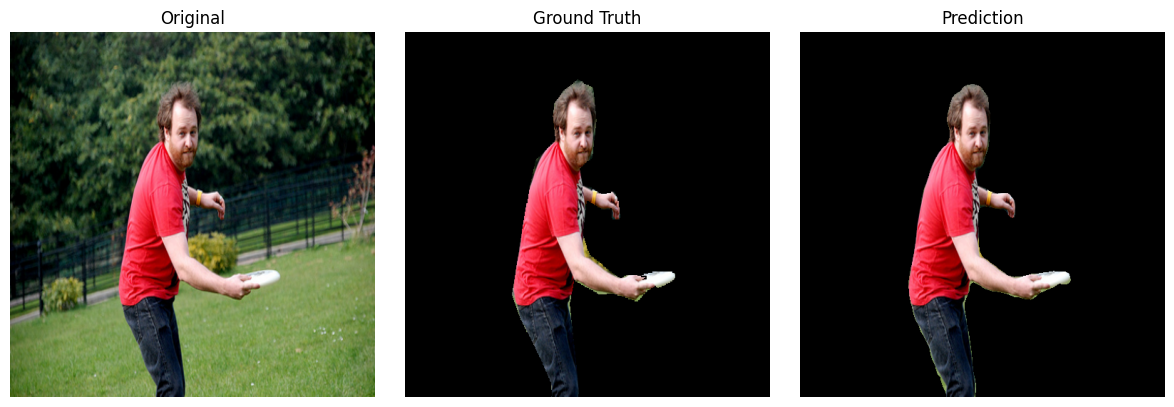

[Image 2] Acc=0.8171, IoU=0.7858, Dice=0.8800


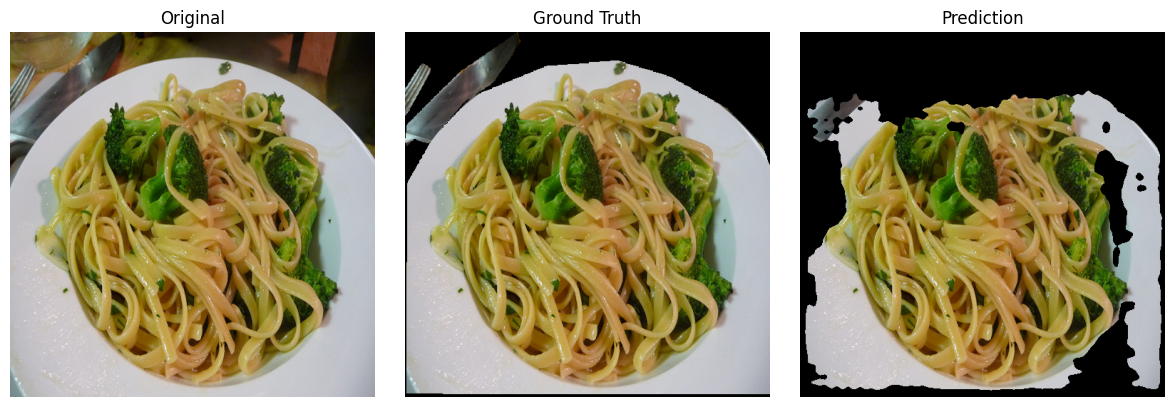

[Image 3] Acc=0.9783, IoU=0.8820, Dice=0.9373


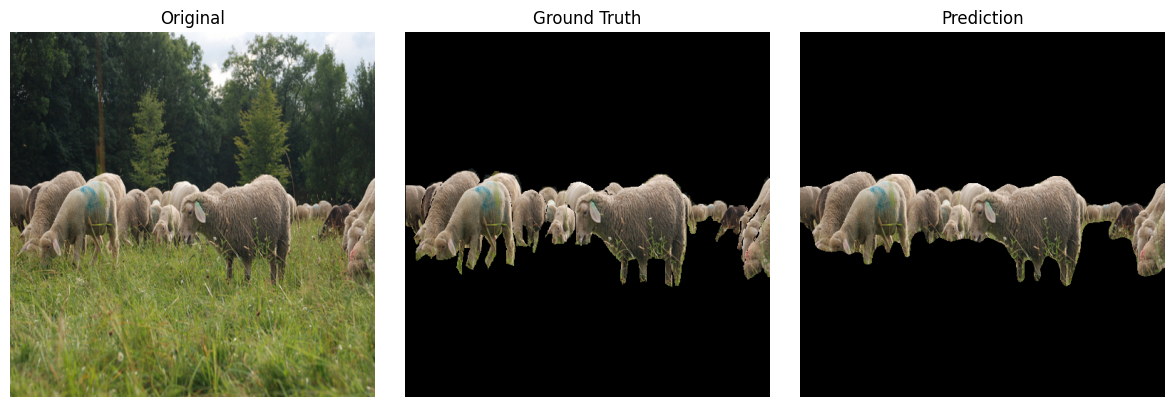

[Image 4] Acc=0.9546, IoU=0.8270, Dice=0.9053


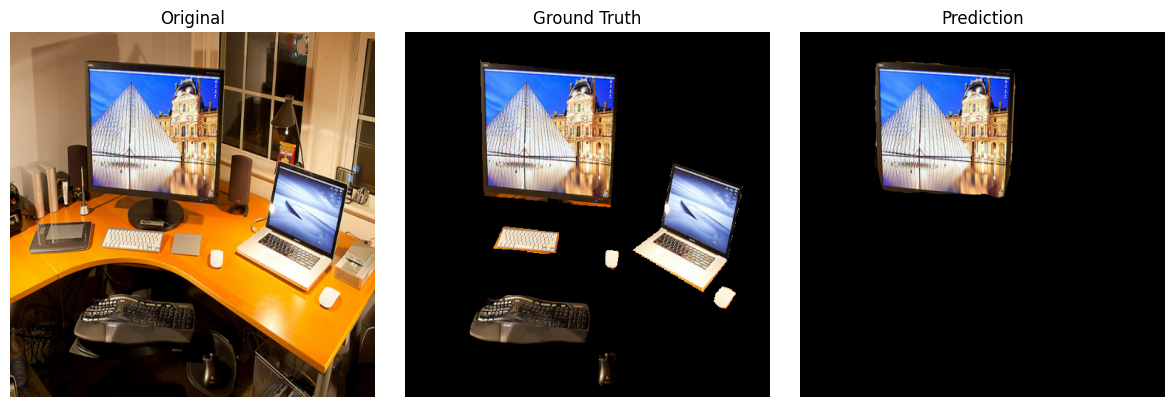

[Image 5] Acc=0.9528, IoU=0.7753, Dice=0.8734


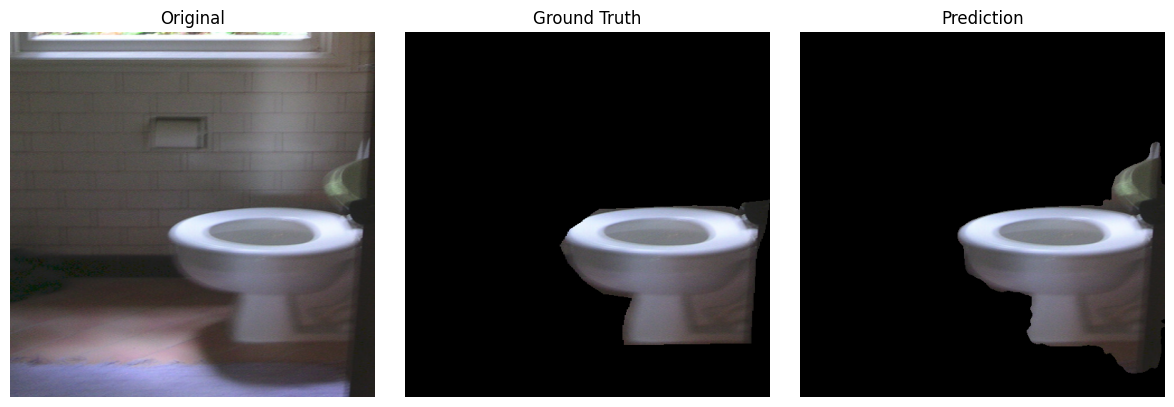

[Image 6] Acc=0.9619, IoU=0.7978, Dice=0.8875


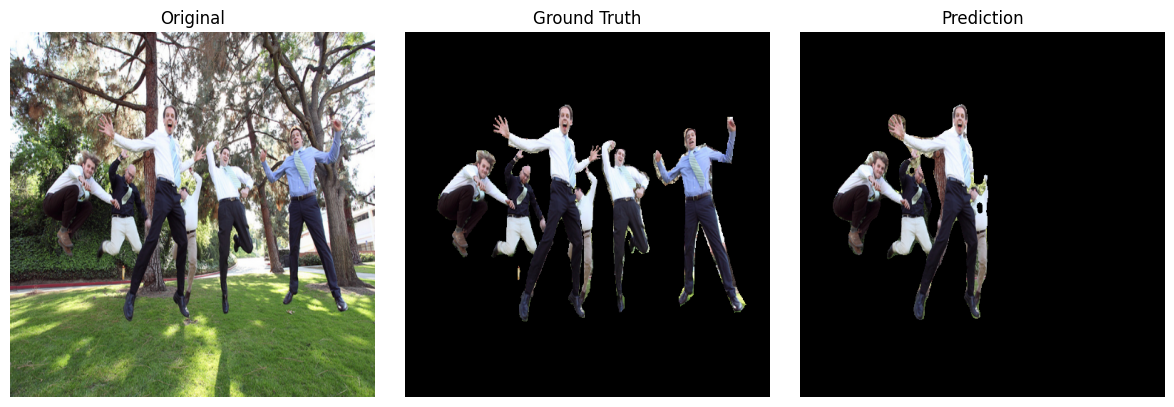

[Image 7] Acc=0.9932, IoU=0.6660, Dice=0.7995


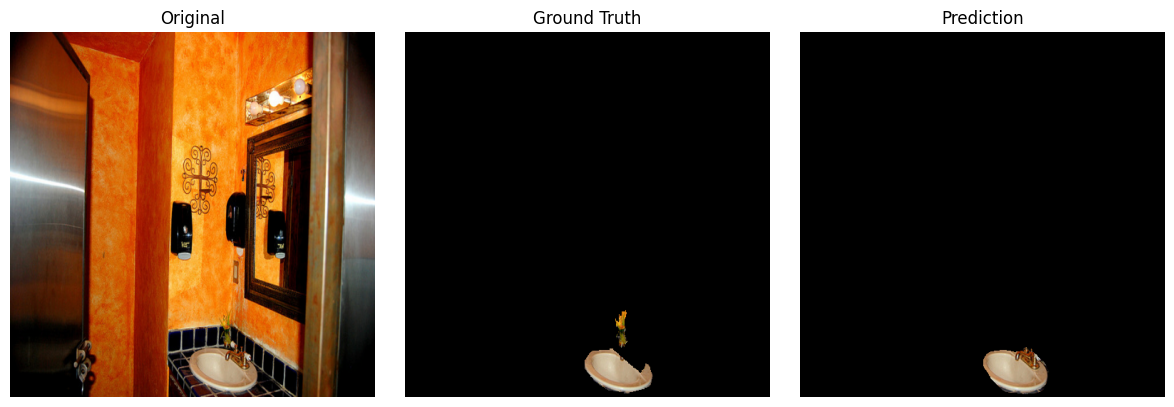

[Image 8] Acc=0.9611, IoU=0.8310, Dice=0.9077


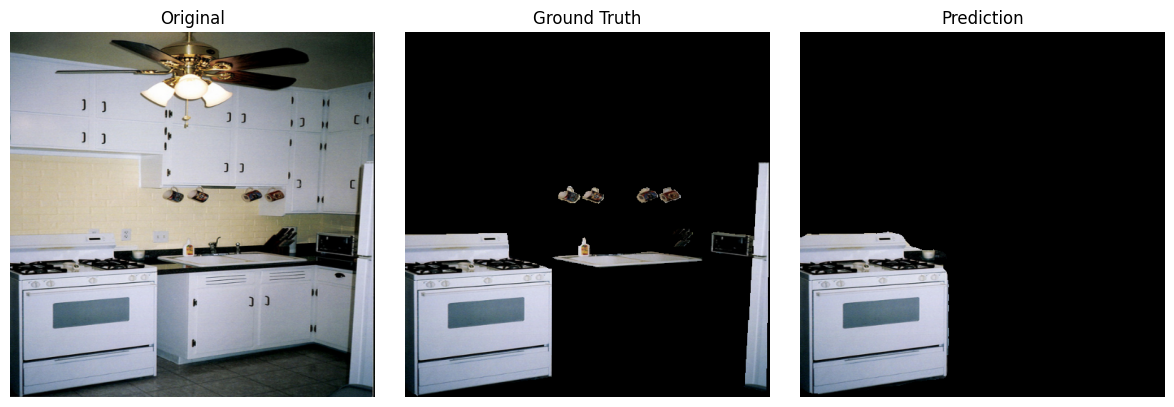

[Image 9] Acc=0.9348, IoU=0.8367, Dice=0.9111


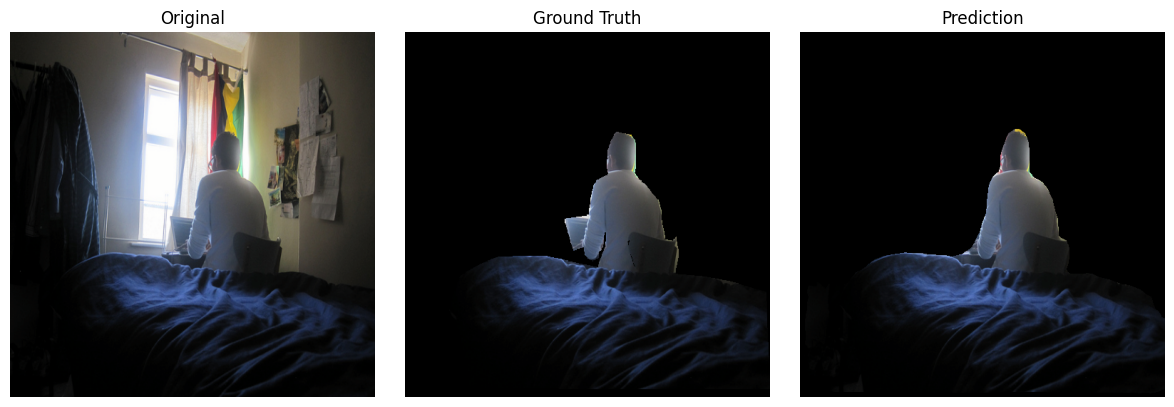

[Image 10] Acc=0.9607, IoU=0.9372, Dice=0.9676


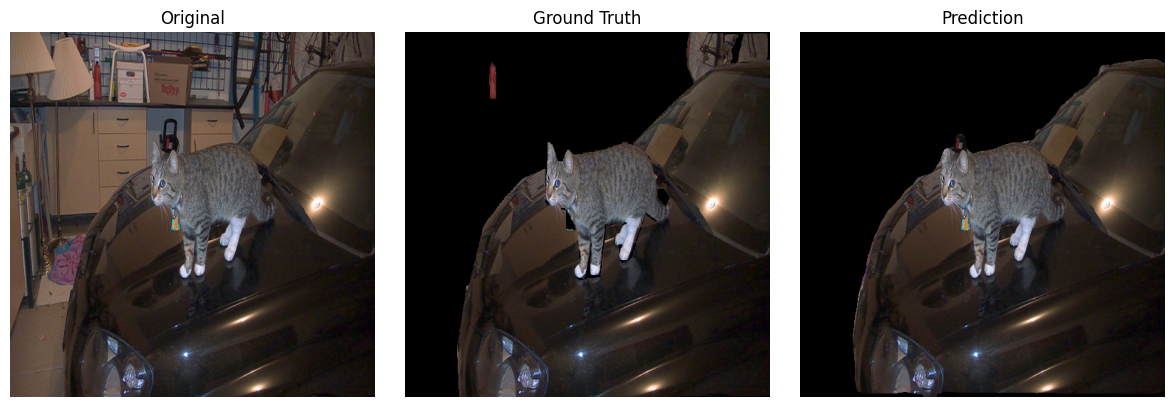

[Image 11] Acc=0.9790, IoU=0.6984, Dice=0.8224


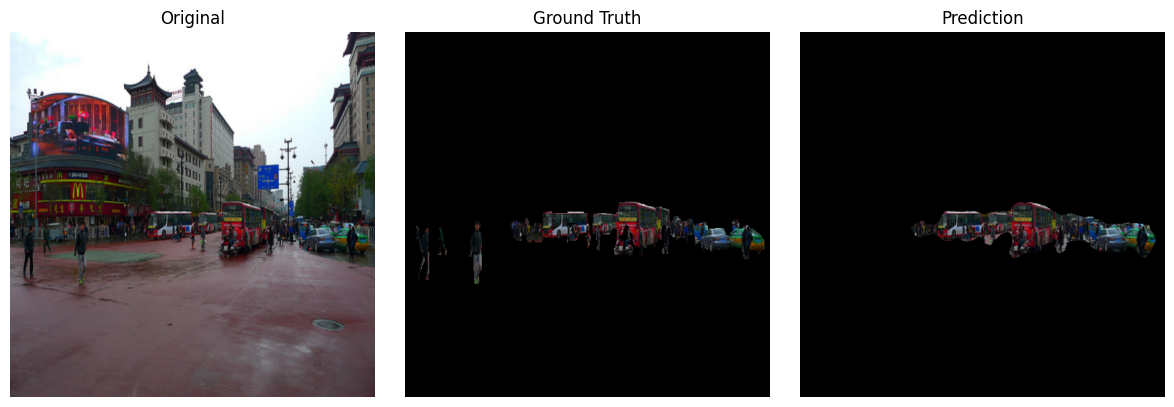

[Image 12] Acc=0.9492, IoU=0.8182, Dice=0.9000


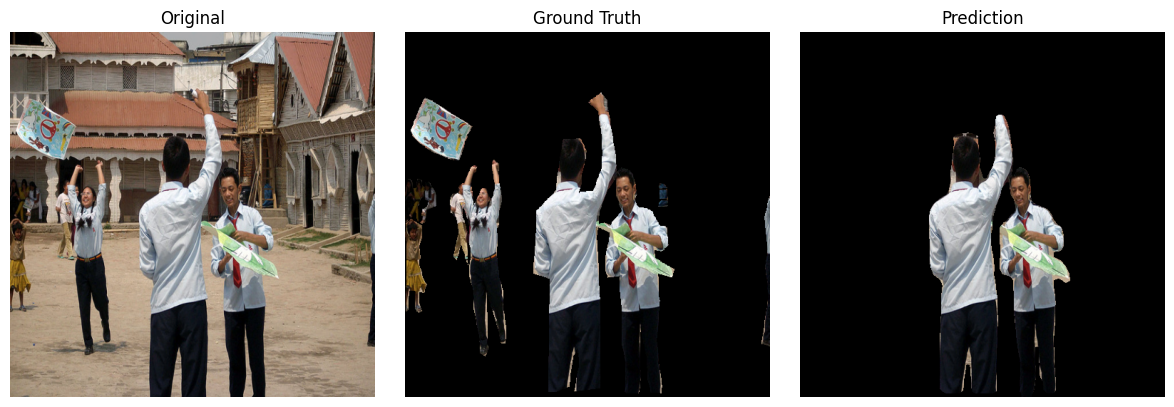

[Image 13] Acc=0.9732, IoU=0.7831, Dice=0.8784


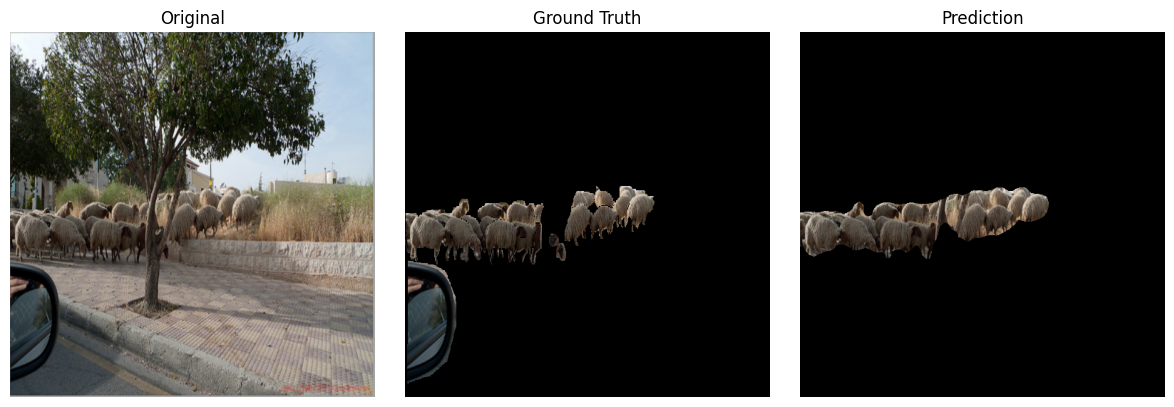

[Image 14] Acc=0.9560, IoU=0.9328, Dice=0.9653


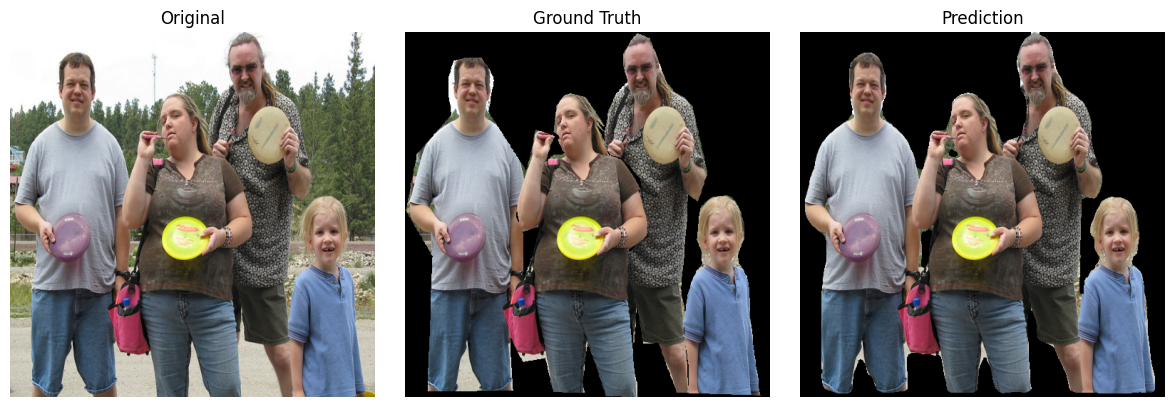

[Image 15] Acc=0.9974, IoU=0.6685, Dice=0.8013


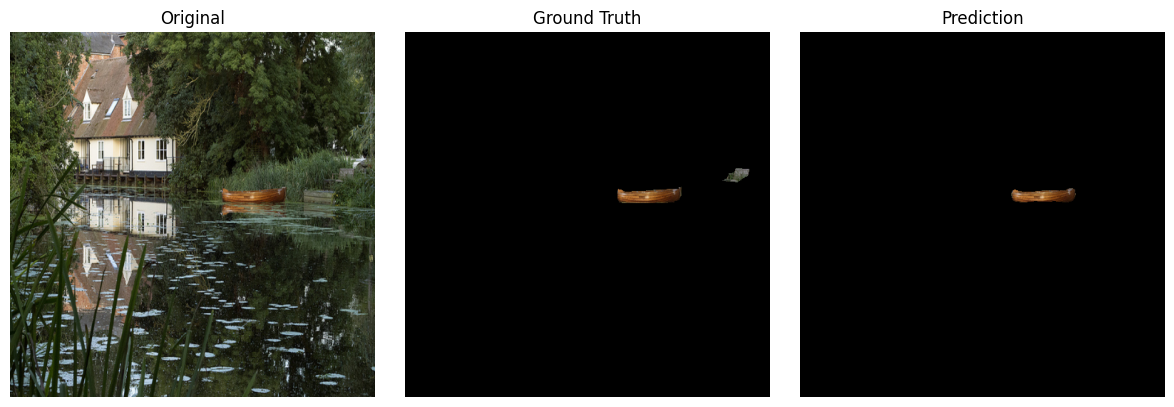

[Image 16] Acc=0.9229, IoU=0.7711, Dice=0.8707


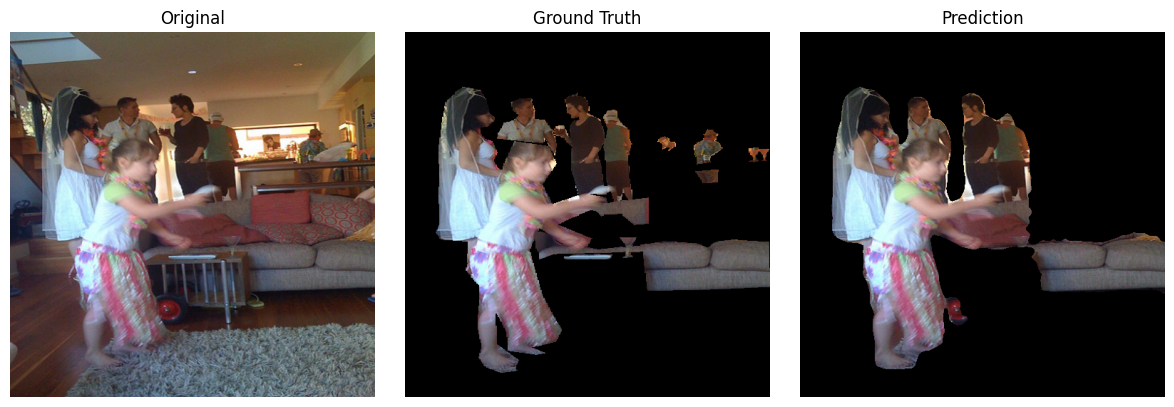

[Image 17] Acc=0.9820, IoU=0.8593, Dice=0.9243


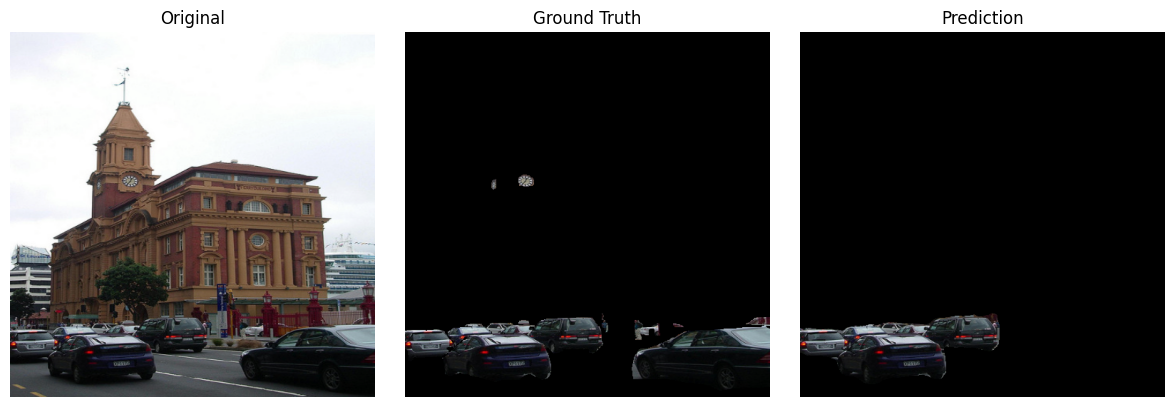

[Image 18] Acc=0.9399, IoU=0.8711, Dice=0.9311


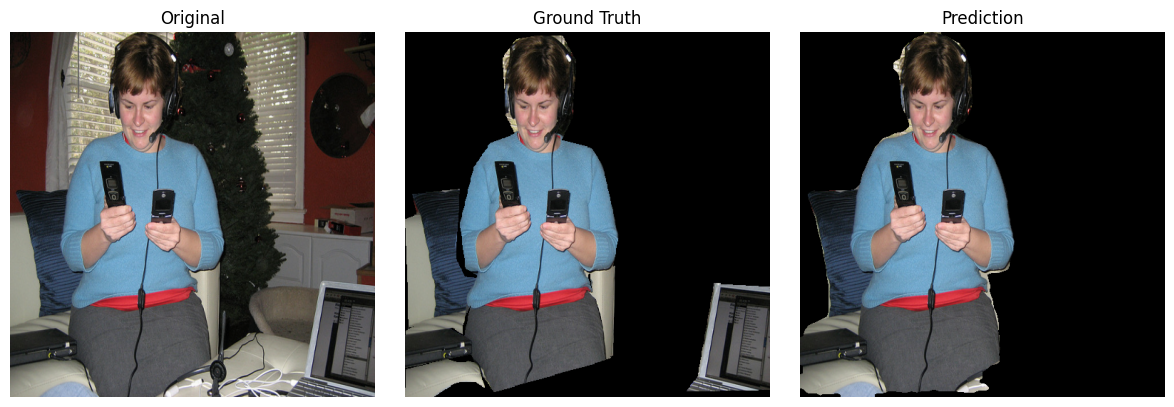

[Image 19] Acc=0.9648, IoU=0.8231, Dice=0.9030


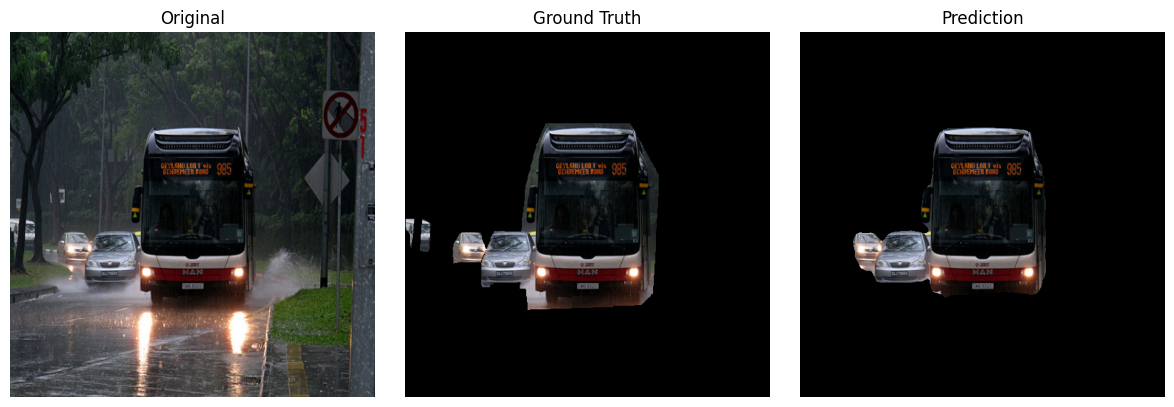

[Image 20] Acc=0.7701, IoU=0.4385, Dice=0.6097


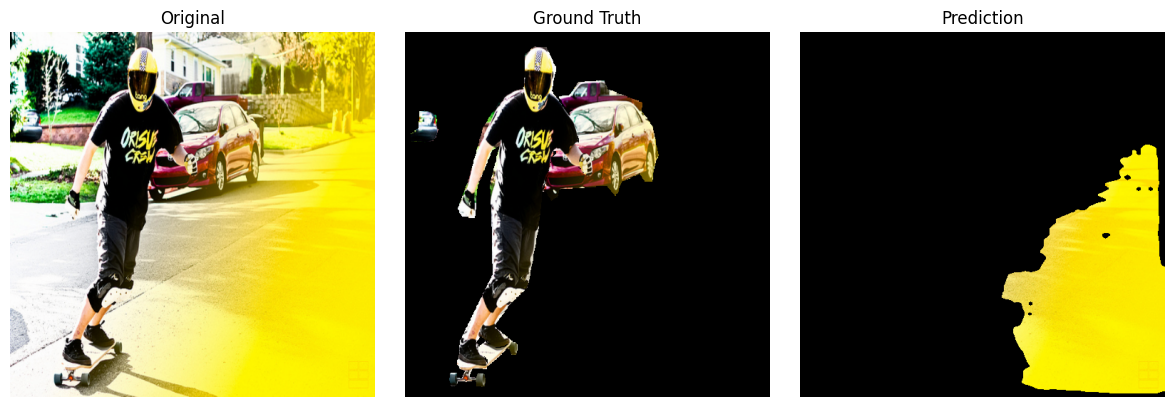


===== Evaluation on Random Samples =====
Pixel Accuracy: 0.9470
Mean IoU: 0.7970
Mean Dice Score: 0.8822


In [10]:
# visualize_predictions_colored.py
import os, random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from albumentations.pytorch import ToTensorV2
import albumentations as A
from pycocotools.coco import COCO
from torchvision.models.segmentation import deeplabv3_resnet101
import cv2

# ----------------------
# Config
# ----------------------
DATA_DIR = r"C:/Users/rahul/Downloads/coco"
ANNOTATIONS = os.path.join(DATA_DIR, "annotations", "instances_val2017.json")
IMAGES_DIR = os.path.join(DATA_DIR, "val2017")
MODEL_PATH = r"C:\Users\rahul\Downloads\infosys project\deeplabv3_resnet101_finetuned.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_SIZE = 512
THRESHOLD = 0.5
print("Device:", DEVICE)

# ----------------------
# Transforms
# ----------------------
val_transforms = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# ----------------------
# Helpers
# ----------------------
def denorm_to_uint8(tchw, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    t = tchw.clone().float().cpu()
    for c in range(3):
        t[c] = t[c]*std[c] + mean[c]
    np_img = (t.permute(1,2,0).numpy()*255.0).clip(0,255).astype(np.uint8)
    return np_img

def keep_largest_component(mask_uint8):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1:
        return mask_uint8
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest).astype(np.uint8)

def postprocess_mask(mask_uint8, morph_kernel=5, keep_largest=True, min_area=128):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel, morph_kernel))
    cleaned = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, k)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, k)
    if keep_largest:
        cleaned = keep_largest_component(cleaned)
    if cleaned.sum() < min_area:
        cleaned[:] = 0
    return cleaned

def color_subject(rgb_uint8, mask_uint8):
    out = rgb_uint8.copy()
    out[mask_uint8 == 0] = 0
    return out

# ----------------------
# Evaluate and visualize (no saving)
# ----------------------
def evaluate_random_images_colored(model, coco_ann, img_root, device, num=20, threshold=THRESHOLD):
    model.eval()
    img_ids = random.sample(coco_ann.getImgIds(), num)

    total_acc = total_iou = total_dice = 0.0
    for idx, img_id in enumerate(img_ids, 1):
        info = coco_ann.loadImgs(img_id)[0]
        path = os.path.join(img_root, info['file_name'])
        orig = np.array(Image.open(path).convert("RGB"))

        # Ground truth union mask at native size
        gt = np.zeros((info['height'], info['width']), dtype=np.uint8)
        for ann in coco_ann.loadAnns(coco_ann.getAnnIds(imgIds=img_id)):
            gt = np.maximum(gt, coco_ann.annToMask(ann).astype(np.uint8))

        # Preprocess to INPUT_SIZE for both model and visualization
        aug = val_transforms(image=orig, mask=gt)
        inp = aug['image'].unsqueeze(0).to(device)        # [1,3,H',W']
        gt_resized = aug['mask'].cpu().numpy().astype(np.uint8)  # [H',W']
        img_resized_uint8 = denorm_to_uint8(aug['image'])        # [H',W',3] uint8

        with torch.no_grad():
            logits = model(inp)['out']
            probs = torch.sigmoid(logits)[0,0].cpu().numpy()

        # Predict at resized resolution
        pred_bin = (probs > threshold).astype(np.uint8)
        pred_bin = postprocess_mask(pred_bin, morph_kernel=5, keep_largest=True, min_area=128)

        # Build colored panels at the SAME resized resolution to avoid shape mismatch
        gt_colored   = color_subject(img_resized_uint8, gt_resized)
        pred_colored = color_subject(img_resized_uint8, pred_bin)

        # Metrics on resized tensors
        preds_t = torch.tensor(probs).unsqueeze(0).unsqueeze(0).to(device)
        gt_t    = torch.tensor(gt_resized).unsqueeze(0).unsqueeze(0).to(device)
        eps = 1e-6
        preds_bin_t = (preds_t > threshold).float()
        intersection = (preds_bin_t * gt_t.float()).view(1, -1).sum()
        union = (preds_bin_t + gt_t.float()).view(1, -1).sum() - intersection
        iou  = ((intersection + eps) / (union + eps)).item()
        dice = ((2*intersection + eps) / (preds_bin_t.view(1,-1).sum() + gt_t.view(1,-1).sum() + eps)).item()
        acc  = (preds_bin_t == gt_t).float().view(1,-1).mean().item()
        total_acc += acc; total_iou += iou; total_dice += dice
        print(f"[Image {idx}] Acc={acc:.4f}, IoU={iou:.4f}, Dice={dice:.4f}")

        # Inline show only
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(img_resized_uint8); plt.title("Original"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(gt_colored);        plt.title("Ground Truth"); plt.axis("off")
        plt.subplot(1,3,3); plt.imshow(pred_colored);      plt.title("Prediction");  plt.axis("off")
        plt.tight_layout()
        plt.show()

    n = len(img_ids)
    print("\n===== Evaluation on Random Samples =====")
    print(f"Pixel Accuracy: {total_acc/n:.4f}")
    print(f"Mean IoU: {total_iou/n:.4f}")
    print(f"Mean Dice Score: {total_dice/n:.4f}")
    print("=======================================")

# ----------------------
# Main
# ----------------------
if __name__ == "__main__":
    # Load model
    model = deeplabv3_resnet101(weights=None)
    model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
    print(f"Loading model from {MODEL_PATH}")
    state = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(state, strict=False)
    model.to(DEVICE)

    # COCO API and run evaluation
    coco = COCO(ANNOTATIONS)
    evaluate_random_images_colored(model, coco, IMAGES_DIR, DEVICE, num=20, threshold=THRESHOLD)
